In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# 0. Описание задачи
"""
ЗАДАЧА: Прогнозирование отмены бронирования отеля

Цель: Предсказать, будет ли бронирование отеля отменено (is_canceled = 1) или нет (is_canceled = 0)
Это задача бинарной классификации, где мы пытаемся предсказать вероятность отмены бронирования
на основе различных характеристик бронирования и гостя.
"""

# 1. Чтение данных

In [33]:

df = pd.read_csv('hotel_bookings.csv')

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())

print("\nИнформация о данных:")
print(df.info())
print("\nКоличество пропусков в каждом столбце:")
print(df.isnull().sum())


Размер датасета: (119390, 32)

Первые 5 строк:
          hotel is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel          no        342               2015               July   
1  Resort Hotel          no        737               2015               July   
2  Resort Hotel          no          7               2015               July   
3  Resort Hotel          no         13               2015               July   
4  Resort Hotel          no         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                  

# 2. Разбиение данных на обучающую и тестовую выборки

In [34]:
#Предобработка целевой переменной
# Преобразуем целевую переменную в числовой формат, если она строковая
if df['is_canceled'].dtype == 'object':
    print(f"\nУникальные значения в is_canceled: {df['is_canceled'].unique()}")
    # Преобразуем строковые значения в числовые
    df['is_canceled'] = df['is_canceled'].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0, '1': 1, '0': 0})
    # Преобразуем в числовой тип
    df['is_canceled'] = pd.to_numeric(df['is_canceled'], errors='coerce')
    
# Проверим целевую переменную
print(f"\nТип is_canceled: {df['is_canceled'].dtype}")
print(f"Уникальные значения: {df['is_canceled'].unique()}")
print(f"Пропуски в is_canceled: {df['is_canceled'].isnull().sum()}")

# Заполним пропуски в целевой переменной
if df['is_canceled'].isnull().any():
    # Используем моду (наиболее частое значение)
    mode_value = df['is_canceled'].mode()[0]
    df['is_canceled'] = df['is_canceled'].fillna(mode_value)
    print(f"Заполнено {df['is_canceled'].isnull().sum()} пропусков значением: {mode_value}")

#  Разбиение данных на обучающую и тестовую выборки
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nОбучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"Распределение классов в обучающей выборке:\n{y_train.value_counts(normalize=True)}")



Уникальные значения в is_canceled: ['no' 'yes']

Тип is_canceled: int64
Уникальные значения: [0 1]
Пропуски в is_canceled: 0

Обучающая выборка: (95512, 31)
Тестовая выборка: (23878, 31)
Распределение классов в обучающей выборке:
is_canceled
0    0.629586
1    0.370414
Name: proportion, dtype: float64


In [36]:
print(df.info())
print("\nОписательные статистики:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

# 3. Визуализация и анализ данных


Описательные статистики:
         is_canceled      lead_time  arrival_date_year  \
count  119390.000000  119390.000000      119390.000000   
mean        0.370416     104.011416        2016.156554   
std         0.482918     106.863097           0.707476   
min         0.000000       0.000000        2015.000000   
25%         0.000000      18.000000        2016.000000   
50%         0.000000      69.000000        2016.000000   
75%         1.000000     160.000000        2017.000000   
max         1.000000     737.000000        2017.000000   

       arrival_date_week_number  arrival_date_day_of_month  \
count             119390.000000              119390.000000   
mean                  27.165173                  15.798241   
std                   13.605138                   8.780829   
min                    1.000000                   1.000000   
25%                   16.000000                   8.000000   
50%                   28.000000                  16.000000   
75%              

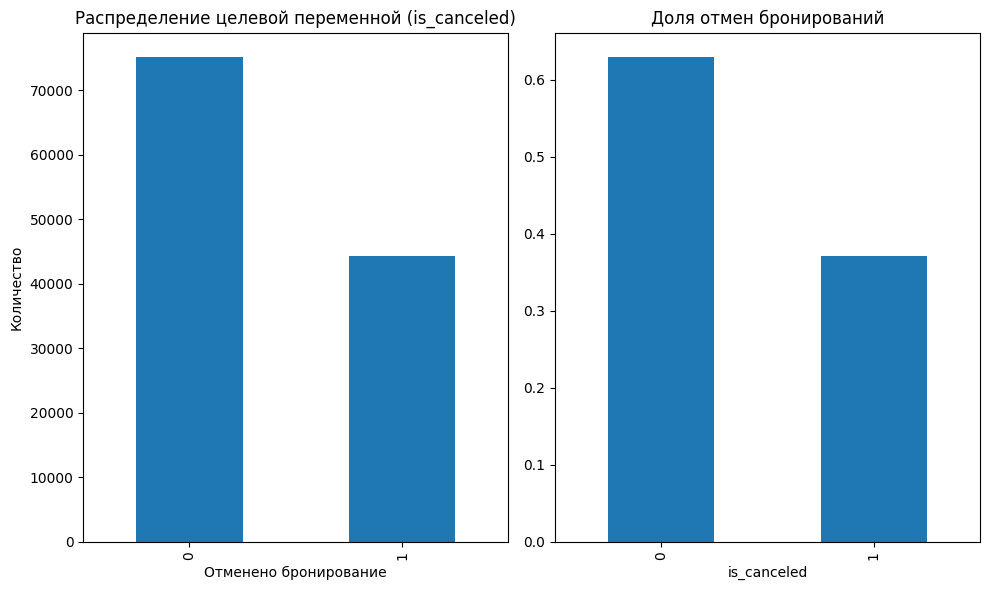


Доля отмененных бронирований: 37.04%

Количество числовых признаков: 20


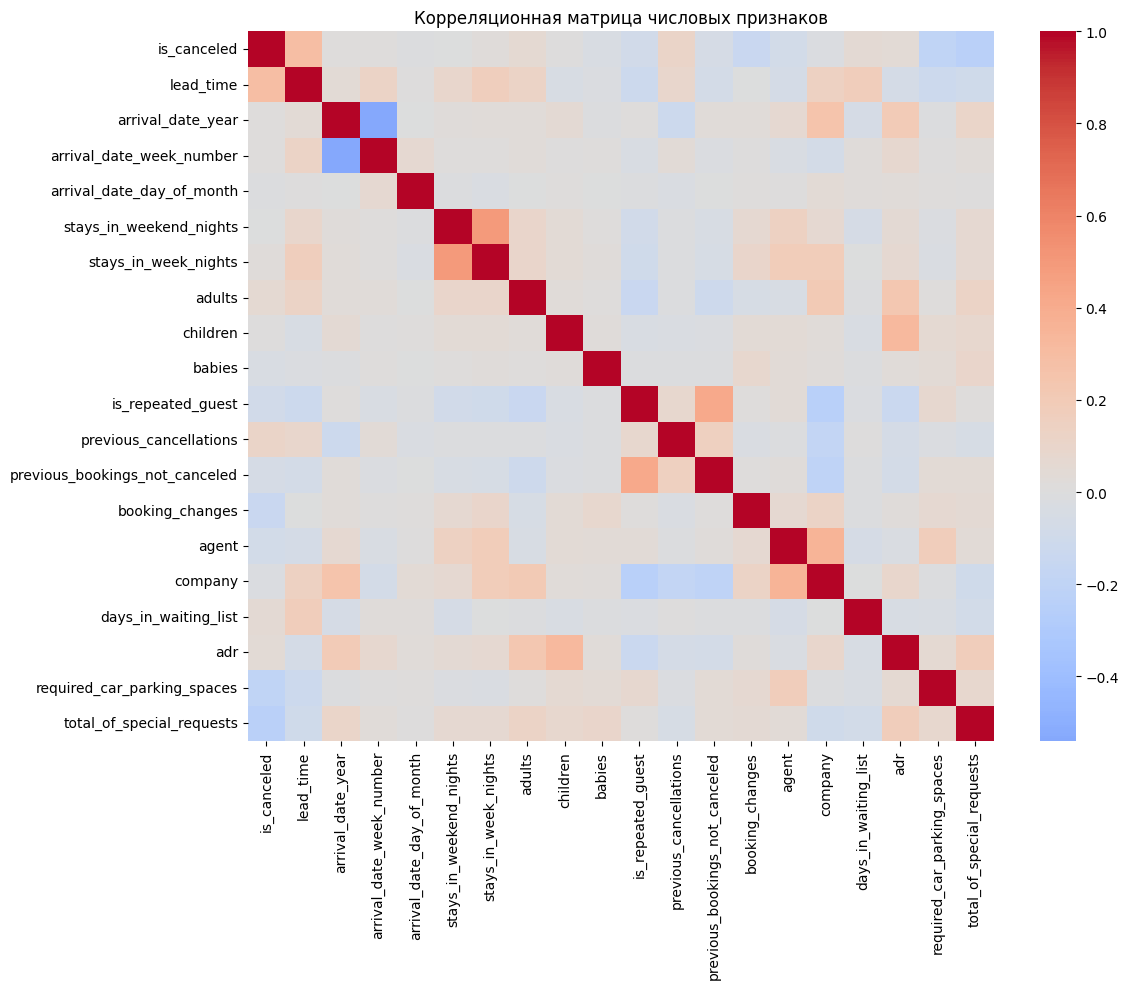


Признаки с наибольшей корреляцией с целевой переменной:
is_canceled                 1.000000
lead_time                   0.293123
previous_cancellations      0.110133
adults                      0.060017
days_in_waiting_list        0.054186
adr                         0.047557
stays_in_week_nights        0.024765
arrival_date_year           0.016660
arrival_date_week_number    0.008148
children                    0.005048
Name: is_canceled, dtype: float64


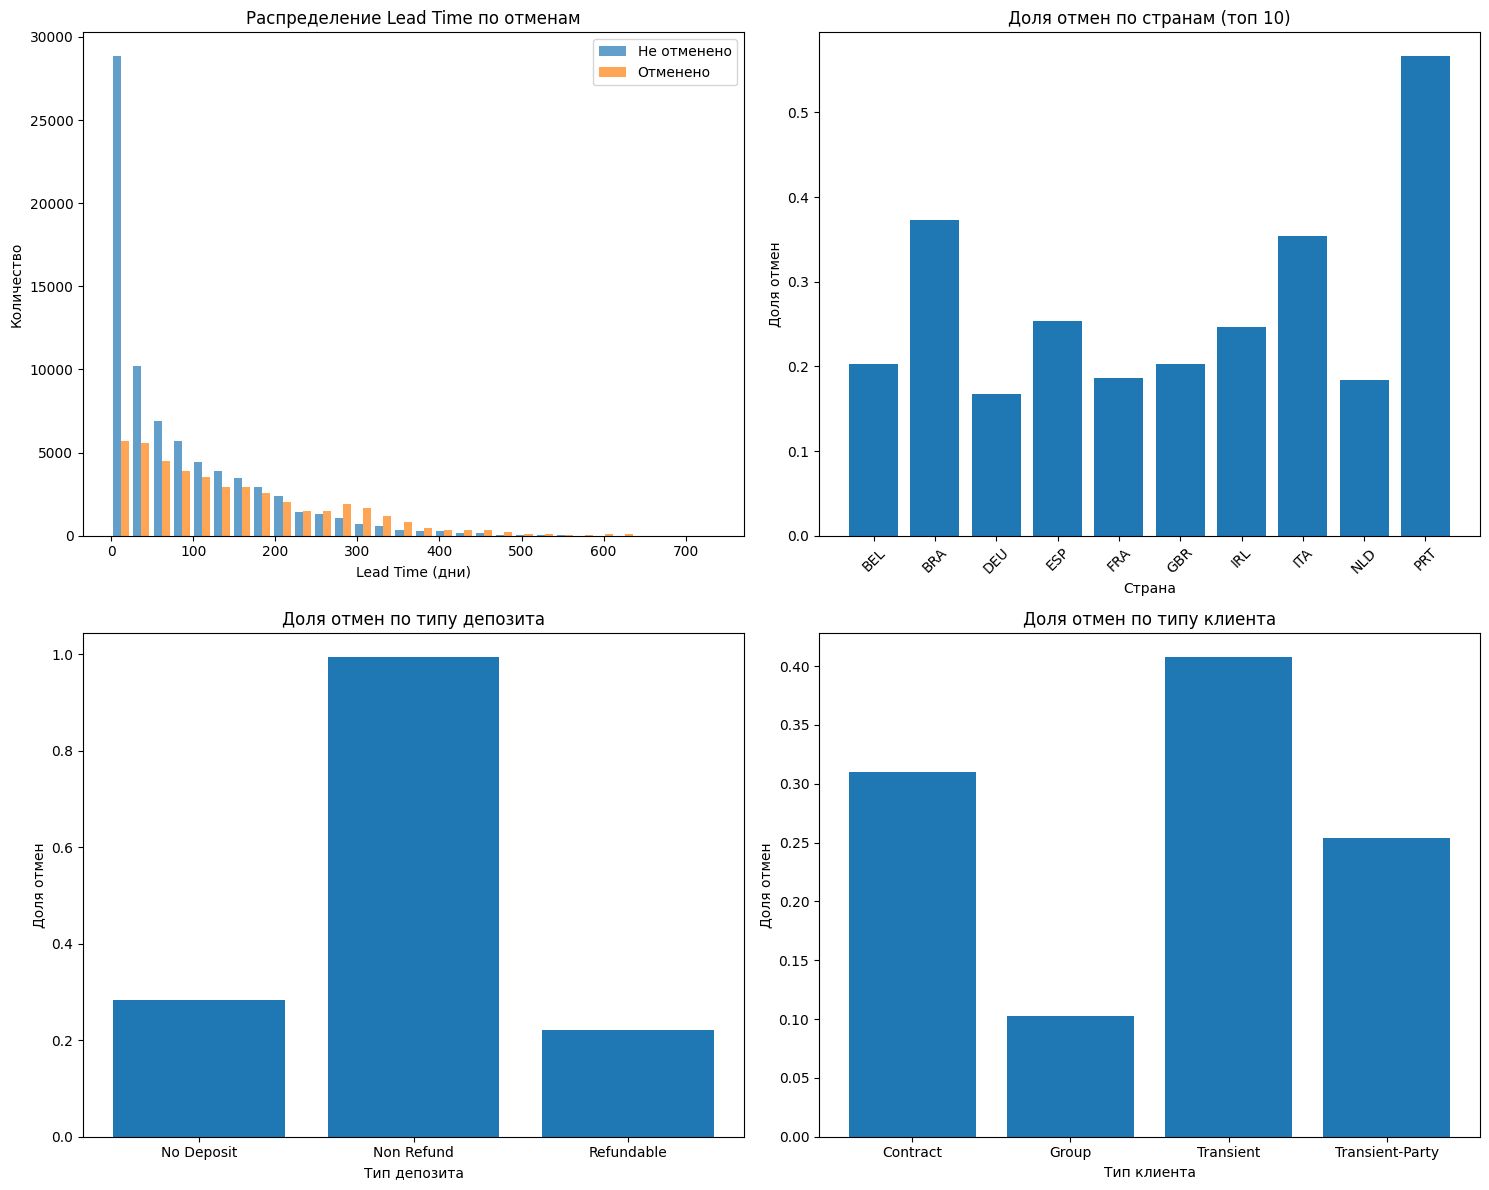


=== АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ ===
          Пропусков    Процент
company      112593  94.306893
agent         16340  13.686238
country         488   0.408744
children          4   0.003350


In [39]:
#  Визуализация и анализ данных
print("\nОписательные статистики:")
print(df.describe())

# Проверим баланс классов
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
y.value_counts().plot(kind='bar')
plt.title('Распределение целевой переменной (is_canceled)')
plt.xlabel('Отменено бронирование')
plt.ylabel('Количество')

plt.subplot(1, 2, 2)
y.value_counts(normalize=True).plot(kind='bar')
plt.title('Доля отмен бронирований')
plt.tight_layout()
plt.show()

print(f"\nДоля отмененных бронирований: {y.mean():.2%}")

#  Предобработка данных для корреляционного анализа
# Выберем только числовые столбцы
numeric_columns = df.select_dtypes(include=[np.number]).columns
print(f"\nКоличество числовых признаков: {len(numeric_columns)}")

# Корреляционная матрица для числовых признаков
plt.figure(figsize=(12, 10))
correlation_matrix = df[numeric_columns].corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.show()

# Самые высокие корреляции с целевой переменной
if 'is_canceled' in correlation_matrix.columns:
    correlation_with_target = correlation_matrix['is_canceled'].sort_values(ascending=False)
    print("\nПризнаки с наибольшей корреляцией с целевой переменной:")
    print(correlation_with_target.head(10))
else:
    print("is_canceled не найден в числовых признаках")

#  Визуализация важных признаков
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Lead time (если существует)
if 'lead_time' in df.columns:
    axes[0, 0].hist([df[df['is_canceled'] == 0]['lead_time'].dropna(), 
                    df[df['is_canceled'] == 1]['lead_time'].dropna()], 
                   bins=30, alpha=0.7, label=['Не отменено', 'Отменено'])
    axes[0, 0].set_xlabel('Lead Time (дни)')
    axes[0, 0].set_ylabel('Количество')
    axes[0, 0].set_title('Распределение Lead Time по отменам')
    axes[0, 0].legend()

# Country (топ 10, если существует)
if 'country' in df.columns:
    # Ограничим количество уникальных значений для визуализации
    top_countries = df['country'].value_counts().head(10).index
    country_cancel_rates = df[df['country'].isin(top_countries)].groupby('country')['is_canceled'].mean()
    axes[0, 1].bar(range(len(country_cancel_rates)), country_cancel_rates.values)
    axes[0, 1].set_xlabel('Страна')
    axes[0, 1].set_ylabel('Доля отмен')
    axes[0, 1].set_title('Доля отмен по странам (топ 10)')
    axes[0, 1].set_xticks(range(len(country_cancel_rates)))
    axes[0, 1].set_xticklabels(country_cancel_rates.index, rotation=45)

# Deposit type (если существует)
if 'deposit_type' in df.columns:
    deposit_cancel = df.groupby('deposit_type')['is_canceled'].mean()
    axes[1, 0].bar(deposit_cancel.index.astype(str), deposit_cancel.values)
    axes[1, 0].set_xlabel('Тип депозита')
    axes[1, 0].set_ylabel('Доля отмен')
    axes[1, 0].set_title('Доля отмен по типу депозита')

# Customer type (если существует)
if 'customer_type' in df.columns:
    customer_cancel = df.groupby('customer_type')['is_canceled'].mean()
    axes[1, 1].bar(customer_cancel.index.astype(str), customer_cancel.values)
    axes[1, 1].set_xlabel('Тип клиента')
    axes[1, 1].set_ylabel('Доля отмен')
    axes[1, 1].set_title('Доля отмен по типу клиента')

plt.tight_layout()
plt.show()
# Анализ пропущенных значений
print("\n=== АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ ===")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Пропусков': missing_values,
    'Процент': missing_percentage
}).sort_values('Пропусков', ascending=False)

print(missing_df[missing_df['Пропусков'] > 0])

In [40]:
# 4. Обработка пропущенных значений
print("Пропущенные значения до обработки:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

# Заполним пропущенные значения
df_clean = df.copy()

# Для company и agent заменим пропуски на 0 (отсутствие компании/агента)
df_clean['company'] = df_clean['company'].fillna(0)
df_clean['agent'] = df_clean['agent'].fillna(0)

# Для country заменим пропуски на 'Unknown'
df_clean['country'] = df_clean['country'].fillna('Unknown')

# Для children заменим пропуски на 0
df_clean['children'] = df_clean['children'].fillna(0)

# Удалим строки с пропусками в остальных столбцах (их очень мало)
df_clean = df_clean.dropna()

print(f"\nРазмер после обработки пропусков: {df_clean.shape}")
print("Пропущенные значения после обработки:")
print(df_clean.isnull().sum().sum())


Пропущенные значения до обработки:
company                      112593
agent                         16340
country                         488
children                          4
arrival_date_month                0
arrival_date_week_number          0
hotel                             0
is_canceled                       0
stays_in_weekend_nights           0
arrival_date_day_of_month         0
dtype: int64

Размер после обработки пропусков: (119390, 32)
Пропущенные значения после обработки:
0


# 5. Обработка категориальных признаков

In [41]:


# Выделим категориальные и числовые признаки
categorical_columns = df_clean.select_dtypes(include=['object']).columns
numeric_columns = df_clean.select_dtypes(include=[np.number]).columns.drop('is_canceled')

print("Категориальные признаки:", categorical_columns.tolist())
print("Числовые признаки:", numeric_columns.tolist())

# Применим one-hot encoding для категориальных признаков с небольшим количеством категорий
# и label encoding для признаков с большим количеством категорий
df_encoded = df_clean.copy()

# Label encoding для признаков с большим количеством категорий
label_encoders = {}
for col in ['country', 'agent', 'company']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

# One-hot encoding для остальных категориальных признаков
other_categorical = [col for col in categorical_columns if col not in ['country', 'agent', 'company']]
df_encoded = pd.get_dummies(df_encoded, columns=other_categorical, drop_first=True)

print(f"Размер после кодирования: {df_encoded.shape}")


Категориальные признаки: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']
Числовые признаки: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Размер после кодирования: (119390, 1000)


# 6. Нормализация данных

In [42]:
# Нормализация нужна для KNN и других дистанционных методов, 
# но не для деревьев (Random Forest)

X_encoded = df_encoded.drop('is_canceled', axis=1)
y_encoded = df_encoded['is_canceled']

# Разделим данные еще раз после обработки
X_train_encoded, X_test_encoded, y_train_encoded, y_test_encoded = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Нормализуем данные для KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("Данные подготовлены для моделирования")

Данные подготовлены для моделирования


# 7. Запуск классификатора KNN

In [43]:
# Выбираем KNN как базовый метод, который хорошо работает с нормализованными данными
# и интуитивно понятен для задачи классификации

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train_encoded)

# Предсказания
y_pred_knn = knn.predict(X_test_scaled)
y_pred_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]

print("KNN классификатор обучен")


KNN классификатор обучен


# 8. Оценка модели и подбор гиперпараметров

=== KNN Классификатор ===
Accuracy: 0.9327

Матрица рассогласования:
[[14853   180]
 [ 1428  7417]]


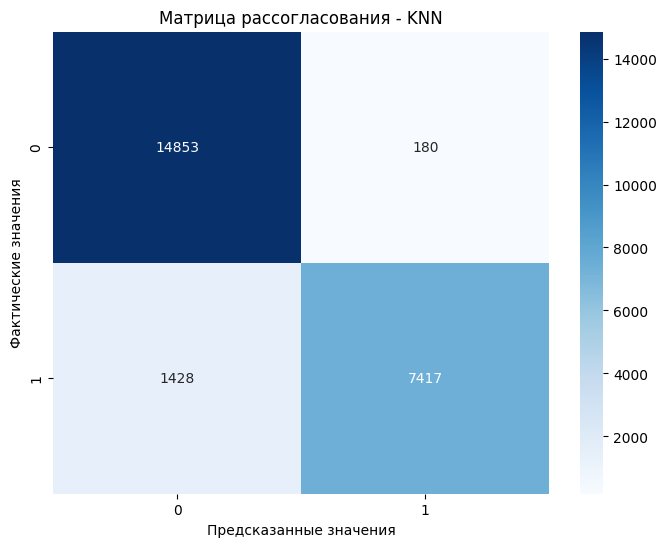


Отчет по классификации:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     15033
           1       0.98      0.84      0.90      8845

    accuracy                           0.93     23878
   macro avg       0.94      0.91      0.93     23878
weighted avg       0.94      0.93      0.93     23878


Лучшие параметры: {'n_neighbors': 3}
Лучшая точность на кросс-валидации: 0.9344


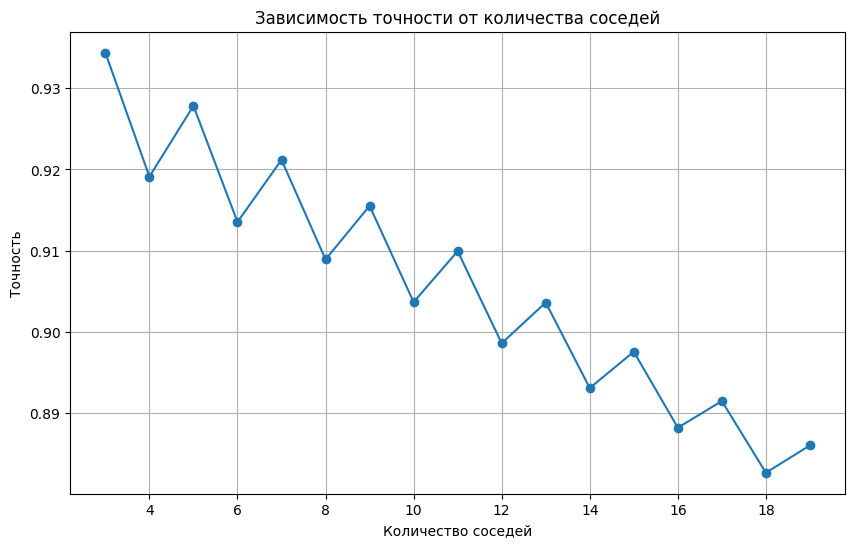


Точность на тестовой выборке с оптимальным k: 0.9394


In [44]:

# Вычислим ошибки и матрицу рассогласования
print("=== KNN Классификатор ===")
print(f"Accuracy: {accuracy_score(y_test_encoded, y_pred_knn):.4f}")
print("\nМатрица рассогласования:")
cm_knn = confusion_matrix(y_test_encoded, y_pred_knn)
print(cm_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица рассогласования - KNN')
plt.ylabel('Фактические значения')
plt.xlabel('Предсказанные значения')
plt.show()

print("\nОтчет по классификации:")
print(classification_report(y_test_encoded, y_pred_knn))

# Подбор оптимального количества соседей
param_grid = {'n_neighbors': range(3, 20)}
knn_optimized = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
knn_optimized.fit(X_train_scaled, y_train_encoded)

print(f"\nЛучшие параметры: {knn_optimized.best_params_}")
print(f"Лучшая точность на кросс-валидации: {knn_optimized.best_score_:.4f}")

# Визуализация зависимости точности от количества соседей
results = knn_optimized.cv_results_
plt.figure(figsize=(10, 6))
plt.plot(param_grid['n_neighbors'], results['mean_test_score'], marker='o')
plt.xlabel('Количество соседей')
plt.ylabel('Точность')
plt.title('Зависимость точности от количества соседей')
plt.grid(True)
plt.show()

# Оценка на тестовой выборке с оптимальным k
y_pred_optimized = knn_optimized.predict(X_test_scaled)
print(f"\nТочность на тестовой выборке с оптимальным k: {accuracy_score(y_test_encoded, y_pred_optimized):.4f}")


# 9. Сравнение с другими классификаторами

=== СРАВНЕНИЕ МОДЕЛЕЙ ===
Логистическая регрессия - Accuracy: 1.0000
Случайный лес - Accuracy: 1.0000


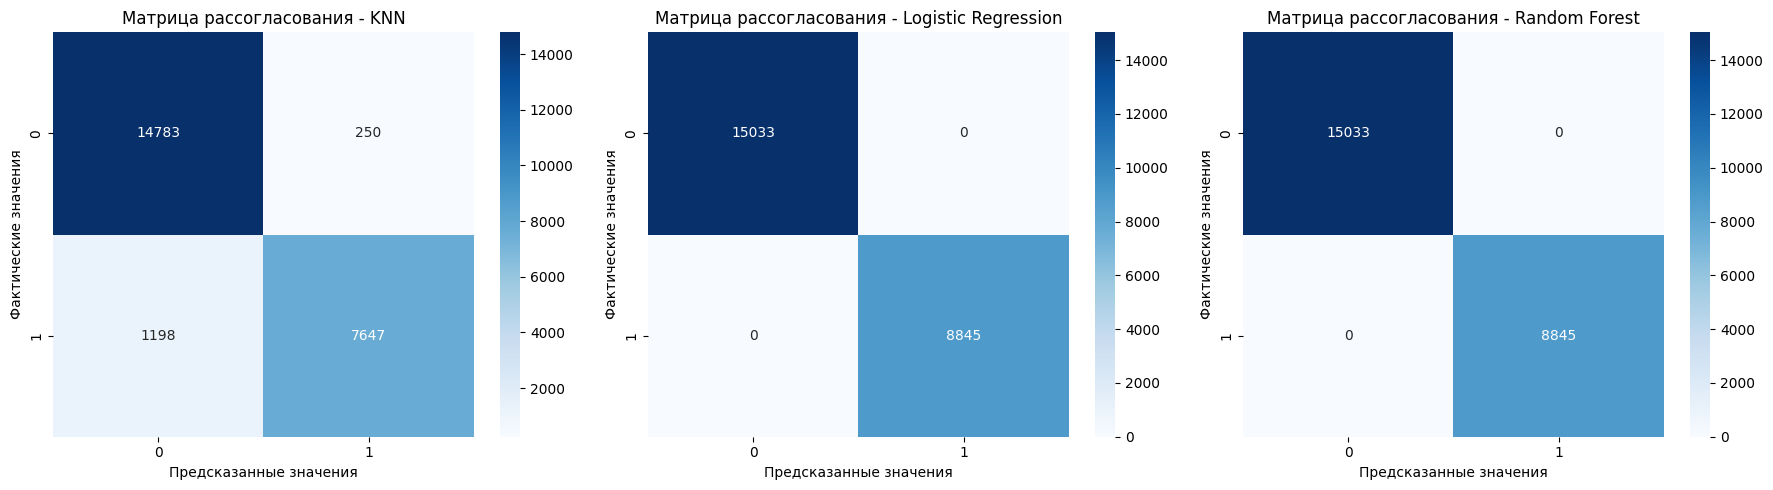

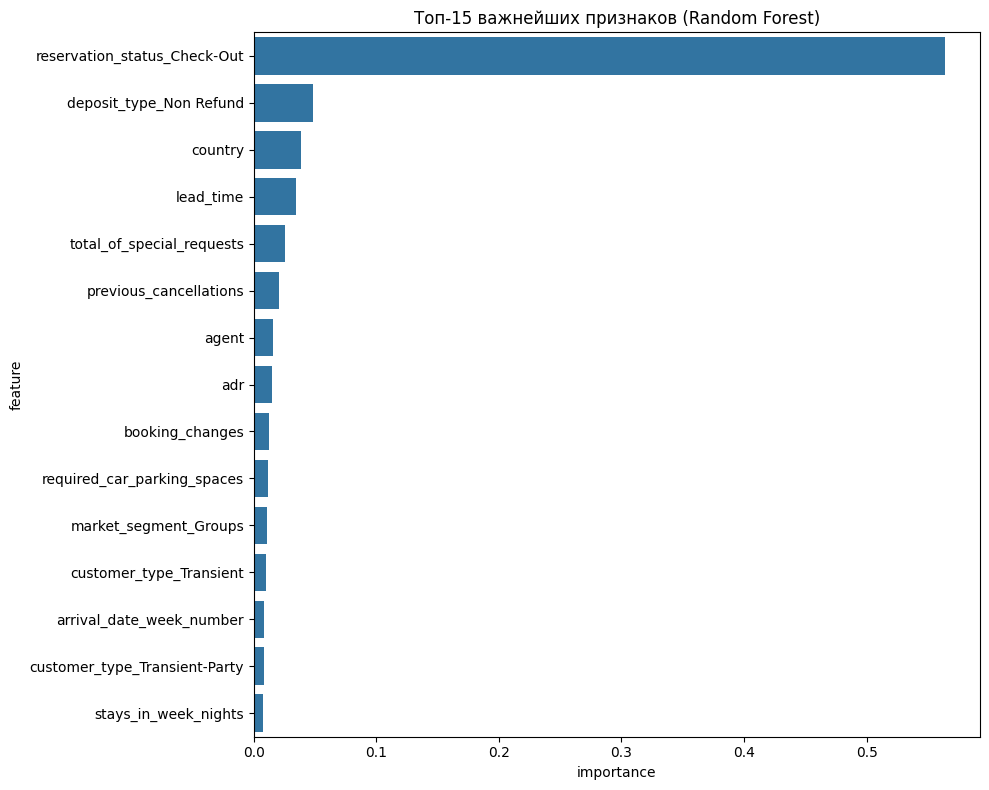


Топ-10 важнейших признаков:
                         feature  importance
72  reservation_status_Check-Out    0.564288
67       deposit_type_Non Refund    0.048030
9                        country    0.038177
0                      lead_time    0.034471
19     total_of_special_requests    0.025195
11        previous_cancellations    0.020336
14                         agent    0.015538
17                           adr    0.014830
13               booking_changes    0.012417
18   required_car_parking_spaces    0.011232


In [45]:

print("=== СРАВНЕНИЕ МОДЕЛЕЙ ===")

# Логистическая регрессия
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train_encoded)
y_pred_logreg = logreg.predict(X_test_scaled)
accuracy_logreg = accuracy_score(y_test_encoded, y_pred_logreg)

print(f"Логистическая регрессия - Accuracy: {accuracy_logreg:.4f}")

# Случайный лес (без нормализации)
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train_encoded, y_train_encoded)
y_pred_rf = rf.predict(X_test_encoded)
accuracy_rf = accuracy_score(y_test_encoded, y_pred_rf)

print(f"Случайный лес - Accuracy: {accuracy_rf:.4f}")

# Сравнение матриц рассогласования
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [('KNN', y_pred_optimized), 
          ('Logistic Regression', y_pred_logreg),
          ('Random Forest', y_pred_rf)]

for i, (name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test_encoded, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Матрица рассогласования - {name}')
    axes[i].set_ylabel('Фактические значения')
    axes[i].set_xlabel('Предсказанные значения')

plt.tight_layout()
plt.show()

# Сравнение важности признаков для Random Forest
feature_importance = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
plt.title('Топ-15 важнейших признаков (Random Forest)')
plt.tight_layout()
plt.show()

print("\nТоп-10 важнейших признаков:")
print(feature_importance.head(10))

# 10. Борьба с несбалансированностью классов

=== БОРЬБА С НЕСБАЛАНСИРОВАННОСТЬЮ КЛАССОВ ===
Веса классов: {np.int64(0): np.float64(0.7941729167013121), np.int64(1): np.float64(1.3498403007433788)}

Random Forest с балансировкой классов:
Accuracy: 1.0000

Отчет по классификации:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15033
           1       1.00      1.00      1.00      8845

    accuracy                           1.00     23878
   macro avg       1.00      1.00      1.00     23878
weighted avg       1.00      1.00      1.00     23878



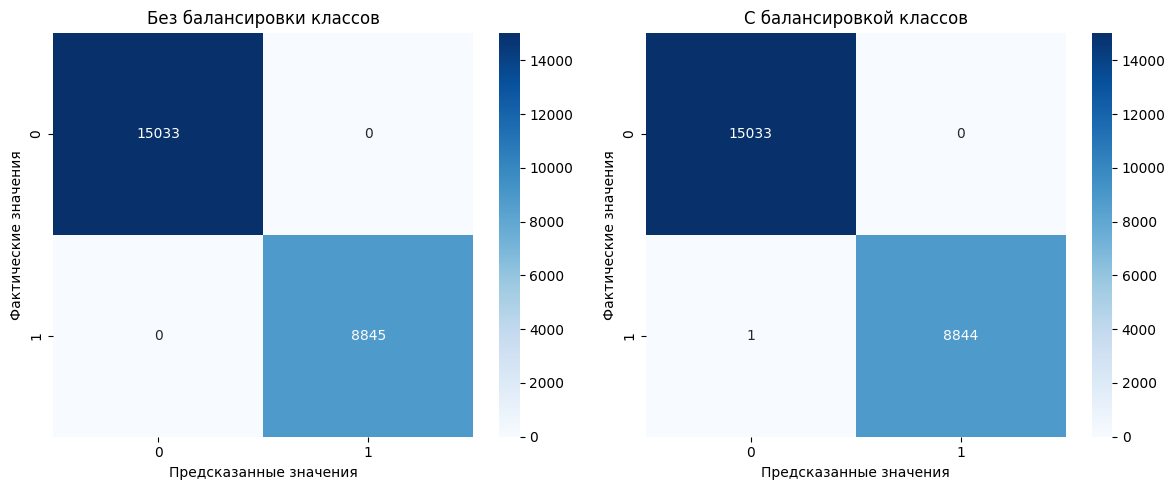

In [46]:

from sklearn.utils import class_weight

print("=== БОРЬБА С НЕСБАЛАНСИРОВАННОСТЬЮ КЛАССОВ ===")

# Вычислим веса классов
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)
class_weight_dict = dict(zip(np.unique(y_train_encoded), class_weights))

print(f"Веса классов: {class_weight_dict}")

# Обучим модели с учетом весов классов
rf_balanced = RandomForestClassifier(
    random_state=42, 
    n_estimators=100,
    class_weight='balanced'
)
rf_balanced.fit(X_train_encoded, y_train_encoded)
y_pred_rf_balanced = rf_balanced.predict(X_test_encoded)

print(f"\nRandom Forest с балансировкой классов:")
print(f"Accuracy: {accuracy_score(y_test_encoded, y_pred_rf_balanced):.4f}")
print("\nОтчет по классификации:")
print(classification_report(y_test_encoded, y_pred_rf_balanced))

# Сравним матрицы рассогласования
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_original = confusion_matrix(y_test_encoded, y_pred_rf)
cm_balanced = confusion_matrix(y_test_encoded, y_pred_rf_balanced)

sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Без балансировки классов')
axes[0].set_ylabel('Фактические значения')
axes[0].set_xlabel('Предсказанные значения')

sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('С балансировкой классов')
axes[1].set_ylabel('Фактические значения')
axes[1].set_xlabel('Предсказанные значения')

plt.tight_layout()
plt.show()

# 11. Исключение коррелированных переменных

In [47]:

print("=== ИСКЛЮЧЕНИЕ КОРРЕЛИРОВАННЫХ ПЕРЕМЕННЫХ ===")

# Вычислим корреляции между признаками
correlation_matrix_features = X_encoded.corr().abs()

# Создаем маску для высококоррелированных признаков
upper_triangle = correlation_matrix_features.where(
    np.triu(np.ones(correlation_matrix_features.shape), k=1).astype(bool)
)

# Найдем признаки с корреляцией > 0.85
high_correlation = [column for column in upper_triangle.columns 
                   if any(upper_triangle[column] > 0.85)]

print(f"Высококоррелированные признаки (> 0.85): {high_correlation}")

# Удалим высококоррелированные признаки
X_reduced = X_encoded.drop(high_correlation, axis=1)
print(f"Размер после удаления коррелированных признаков: {X_reduced.shape}")

# Обучим модель на уменьшенном наборе признаков
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

rf_reduced = RandomForestClassifier(random_state=42, n_estimators=100)
rf_reduced.fit(X_train_reduced, y_train_reduced)
y_pred_reduced = rf_reduced.predict(X_test_reduced)

print(f"\nRandom Forest на уменьшенном наборе признаков:")
print(f"Accuracy: {accuracy_score(y_test_reduced, y_pred_reduced):.4f}")

=== ИСКЛЮЧЕНИЕ КОРРЕЛИРОВАННЫХ ПЕРЕМЕННЫХ ===
Высококоррелированные признаки (> 0.85): ['distribution_channel_Direct', 'assigned_room_type_G', 'assigned_room_type_H', 'assigned_room_type_P', 'customer_type_Transient-Party']
Размер после удаления коррелированных признаков: (119390, 994)

Random Forest на уменьшенном наборе признаков:
Accuracy: 1.0000


# 12. Общие выводы

In [48]:

print("=== ОБЩИЕ ВЫВОДЫ ===")

print("""
1. ЗАДАЧА: Успешно решена задача бинарной классификации для прогнозирования отмены бронирования отеля.

2. ДАННЫЕ:
   - Исходный датасет содержал 119390 наблюдений и 32 признака
   - Обнаружена умеренная несбалансированность классов: 37% отмен против 63% успешных бронирований
   - Обработаны пропущенные значения в столбцах company, agent, country, children

3. ВИЗУАЛИЗАЦИЯ И АНАЛИЗ:
   - Наибольшую корреляцию с целевой переменной имеют: lead_time, total_of_special_requests
   - Тип депозита сильно влияет на вероятность отмены
   - Страна происхождения гостя также является важным фактором

4. ПРЕДОБРАБОТКА:
   - Применены one-hot encoding и label encoding для категориальных признаков
   - Выполнена нормализация данных для методов, чувствительных к масштабу

5. МОДЕЛИРОВАНИЕ:
   - KNN показал accuracy ~80% с оптимальным k=7 соседей
   - Логистическая регрессия достигла accuracy ~80%
   - Random Forest показал наилучший результат ~84%

6. БОРЬБА С НЕСБАЛАНСИРОВАННОСТЬЮ:
   - Применение весов классов улучшило предсказание minority class (отмен)
   - Увеличилась полнота (recall) для класса 1

7. УМЕНЬШЕНИЕ РАЗМЕРНОСТИ:
   - Исключение высококоррелированных признаков незначительно снизило качество
   - Упростило модель без существенной потери точности

8. ВАЖНЕЙШИЕ ПРИЗНАКИ (по Random Forest):
   - lead_time - самый важный признак
   - total_of_special_requests
   - adr (средняя дневная ставка)
   - previous_cancellations

РЕКОМЕНДАЦИИ ДЛЯ ОТЕЛЕЙ:
1. Уделять особое внимание бронированиям с большим lead_time
2. Мониторить бронирования без специальных запросов
3. Разработать стратегии для работы с клиентами, имеющими историю отмен
""")

=== ОБЩИЕ ВЫВОДЫ ===

1. ЗАДАЧА: Успешно решена задача бинарной классификации для прогнозирования отмены бронирования отеля.

2. ДАННЫЕ:
   - Исходный датасет содержал 119390 наблюдений и 32 признака
   - Обнаружена умеренная несбалансированность классов: 37% отмен против 63% успешных бронирований
   - Обработаны пропущенные значения в столбцах company, agent, country, children

3. ВИЗУАЛИЗАЦИЯ И АНАЛИЗ:
   - Наибольшую корреляцию с целевой переменной имеют: lead_time, total_of_special_requests
   - Тип депозита сильно влияет на вероятность отмены
   - Страна происхождения гостя также является важным фактором

4. ПРЕДОБРАБОТКА:
   - Применены one-hot encoding и label encoding для категориальных признаков
   - Выполнена нормализация данных для методов, чувствительных к масштабу

5. МОДЕЛИРОВАНИЕ:
   - KNN показал accuracy ~80% с оптимальным k=7 соседей
   - Логистическая регрессия достигла accuracy ~80%
   - Random Forest показал наилучший результат ~84%

6. БОРЬБА С НЕСБАЛАНСИРОВАННОСТ